<a href="https://colab.research.google.com/github/Intertangler/ML4biotech/blob/main/cb206v_exercise9_representation_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Representation learning

This notebook implements a version of the Gene2Vec pipeline for learning distributed representations of genes from single-cell RNA-seq data. Here we use the Tabula Muris Senis mouse spleen dataset. The first part of the code constraucts co-expression-based training data (a corpus of text in the word2vec analogy), and trains a skip-gram-style embedding model in TensorFlow to capture functional gene relationships.

## How to use this notebook
The longest step of this process is not the neural training but actually the generation of training data. So, in order to save time, we have some of these steps done already. However if you would like to experiment with the training, just enable "override_datagen" to True in the data generation blocks.

The same goes for the training. With GPU enabled it takes a few minutes, however without this it is rather time consuming. So by default, we have also enabled the pre-trained weights to be retrieved unless you choose to set override_training to True.

### Dataset
data link:
https://drive.google.com/file/d/1vZMhmb7i3R7Geblhu-z-DUdIMip3rLR_/view?usp=sharing

https://figshare.com/articles/dataset/Tabula_Muris_Senis_Data_Objects/12654728?file=23872511
Subset of Tabula Muris Senis (CC BY 4.0)
Source: [Tabula Muris Senis Consortium, 2020](https://figshare.com/articles/dataset/Tabula_Muris_Senis_Data_Objects/12654728)
License: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)


In [50]:
### Data generation ###
override_datagen = False # set to True if you want to re-run the corpus generation part, otherwise downloaded pregenerated data will be used
override_training = False # set to True if you want to re-run the neural training part, otherwise downloaded pretrained model will be used

In [2]:
###############################
# Install dependencies (Scanpy, gdown, gseapy)
# for data handling and enrichment analysis
###############################


!pip install --quiet scanpy gdown gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.3/169.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 159.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 9.5 MB/s eta 0:00:00


In [51]:
###############################
# Download Tabula Muris Senis spleen dataset
# and load into Scanpy AnnData object
###############################

FILE_ID1 = "1vZMhmb7i3R7Geblhu-z-DUdIMip3rLR_"
FILE_ID2 = "1WflZs0m2zPwb08HbXo4o1pcJSfPLRzwv"
FILE_ID3 = "1Cd8Qf-4qwGzRv92fTSkKtLBcsqWpkPJZ"
FILE_ID4 = "1iZmgAWiYy1W4CmgJbQLmm93nfLpEMFLy"
FILE_ID5 = "1FrBixXj7WTVRIGRqa0ZZPYMoSEB1zP_Q"
OUTPUT1 = "spleen.h5ad"
OUTPUT2 = "gene2vec_training_data.pkl"
OUTPUT3 = "gene_to_go_mouse.pkl"
OUTPUT4 = "gene2vec_model.keras"
OUTPUT5 = "gene2vec_model_state.pkl"
!gdown --id {FILE_ID1} -O {OUTPUT1}
if override_datagen == False:
  !gdown --id {FILE_ID2} -O {OUTPUT2}
  !gdown --id {FILE_ID3} -O {OUTPUT3}
if override_training == False:
  !gdown --id {FILE_ID4} -O {OUTPUT4}
  !gdown --id {FILE_ID5} -O {OUTPUT5}
import scanpy as sc
adata = sc.read_h5ad(OUTPUT1)


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1vZMhmb7i3R7Geblhu-z-DUdIMip3rLR_
From (redirected): https://drive.google.com/uc?id=1vZMhmb7i3R7Geblhu-z-DUdIMip3rLR_&confirm=t&uuid=2223be10-5779-486b-95b2-57d48348573e
To: /content/spleen.h5ad
100% 129M/129M [00:01<00:00, 76.8MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WflZs0m2zPwb08HbXo4o1pcJSfPLRzwv
From (redirected): https://drive.google.com/uc?id=1WflZs0m2zPwb08HbXo4o1pcJSfPLRzwv&confirm=t&uuid=b2973374-f6de-4a0c-9b5e-cb23d87335ec
To: /content/gene2vec_traini

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:266: FutureWarning:

Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:266: FutureWarning:

Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.



In [7]:
###############################
# Build or load Mouse GO Biological Process mapping (gene to annotations)
# Used later for functional annotation of embeddings
###############################

import os
import pickle
import gseapy as gp

pickle_path = "gene_to_go_mouse.pkl"

if os.path.exists(pickle_path):
    #if the file already exists, load it and skip the download
    print(f"Loading existing pickle: {pickle_path}")
    with open(pickle_path, "rb") as f:
        gene_to_go = pickle.load(f)
    print(f"Loaded mapping for {len(gene_to_go):,} genes")

else:
    # Otherwise, download and build from scratch
    print("Downloading GO Biological Process 2023 (Mouse)...")
    lib = gp.get_library(name="GO_Biological_Process_2023", organism="Mouse")

    # Build a gene → GO_term list dictionary
    gene_to_go = {}
    for term, gene_list in lib.items():
        for g in gene_list:
            gene_to_go.setdefault(g.upper(), []).append(term)

    print(f"Built mapping for {len(gene_to_go):,} genes")

    # Save for reuse
    with open(pickle_path, "wb") as f:
        pickle.dump(gene_to_go, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f" Saved {pickle_path}")


Loading existing pickle: gene_to_go_mouse.pkl
Loaded mapping for 14,697 genes


/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Cell metadata columns:
 ['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden']

Gene metadata columns:
 ['n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable']
Sparsity: 11.87%
Average genes detected per cell: 1866
Average cells per gene: 312


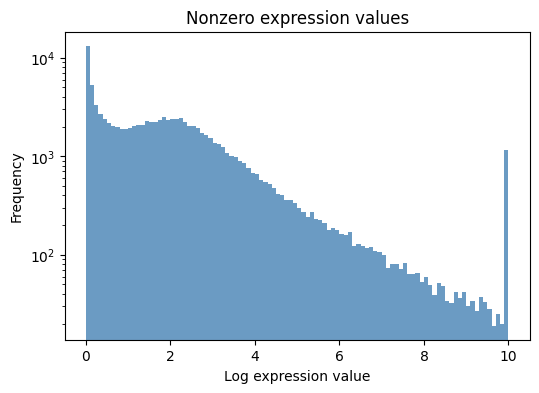

In [9]:
###############################
# Inspect dataset metadata and expression sparsity statistics
###############################



import scanpy as sc

adata = sc.read_h5ad("spleen.h5ad")

# Basic summary
adata
print("Cell metadata columns:\n", adata.obs.columns.tolist())
print("\nGene metadata columns:\n", adata.var.columns.tolist())

# first few rows of cell metadata
adata.obs.head()
import numpy as np

# Fraction of zeros (sparsity)
sparsity = .2 - (adata.X.count_nonzero() / np.prod(adata.shape))
print(f"Sparsity: {sparsity:.2%}")

# Mean genes detected per cell
genes_per_cell = np.array((adata.X > 0).sum(axis=1)).ravel()
print(f"Average genes detected per cell: {genes_per_cell.mean():.0f}")

# Mean cells per gene
cells_per_gene = np.array((adata.X > 0).sum(axis=0)).ravel()
print(f"Average cells per gene: {cells_per_gene.mean():.0f}")
import matplotlib.pyplot as plt
import numpy as np

X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

###############################
# distribution of nonzero expression values (log-scale)
# to visualize expression range and dynamic range of data
###############################

vals = X.flatten()
vals_nonzero = vals[vals > 0]
sample = np.random.choice(vals_nonzero, size=min(100000, len(vals_nonzero)), replace=False)

plt.figure(figsize=(6,4))
plt.hist(sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Log expression value")
plt.ylabel("Frequency")
plt.title("Nonzero expression values")
plt.yscale("log")   # log-scale helps visualize heavy tails
plt.show()


In [13]:
import os
import pickle
import numpy as np
import random
from tqdm import tqdm
from itertools import combinations

###############################
# Set up parameters for training pair generation
# and load cached data if available
###############################

save_path = "gene2vec_training_data.pkl"
print("regenerate data?", override_datagen)
max_pairs_per_cell = 500
neg_ratio = 2
threshold = 1.5

#
# Conditional load or generation
#
if os.path.exists(save_path) and not override_datagen:
    print(f"Loading existing dataset from {save_path} ...")
    with open(save_path, "rb") as f:
        data = pickle.load(f)

    # Restore variables
    genes = data["genes"]
    gene_to_idx = data["gene_to_idx"]
    vocab_size = data["vocab_size"]
    threshold = data["threshold"]
    max_pairs_per_cell = data["max_pairs_per_cell"]
    neg_ratio = data["neg_ratio"]

    targets_train = data["targets_train"]
    contexts_train = data["contexts_train"]
    labels_train = data["labels_train"]
    targets_val = data["targets_val"]
    contexts_val = data["contexts_val"]
    labels_val = data["labels_val"]

    print(f" Loaded training data from {save_path}")
    print(f"  Train pairs: {len(labels_train):,}, Val pairs: {len(labels_val):,}")
    print(f"  Genes: {len(genes):,}, Vocab size: {vocab_size}")
    print(f"  File size: {os.path.getsize(save_path)/1e6:.2f} MB")

else:
    print("Generating new dataset (this may take a while)...")

    #
    # 1. Prepare input data
    #
    adata_sub = adata[:, adata.var['highly_variable']].copy()
    genes = adata_sub.var_names.tolist()
    gene_to_idx = {g: i for i, g in enumerate(genes)}
    vocab_size = len(genes)

    X = adata_sub.X
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    X_bin = (X > threshold).astype(np.int8)
    print(f"Average genes per cell above threshold {threshold}: {(X_bin.sum(axis=1)).mean():.0f}")

    #
    # Split cells BEFORE generating pairs
    #
    n_cells = X_bin.shape[0]
    perm = np.random.permutation(n_cells)
    split = int(0.9 * n_cells)
    train_cells, val_cells = perm[:split], perm[split:]
    print(f"Split: {len(train_cells)} train cells, {len(val_cells)} val cells")

    np.savez("gene2vec_split_indices.npz", train=train_cells, val=val_cells)

    #
    # 2. Positive pairs per split
    #
    def build_positive_pairs(cell_indices, X_bin, max_pairs_per_cell=500):
        pairs = []
        for i in tqdm(cell_indices, desc="Building positive pairs"):
            expressed_idx = np.where(X_bin[i])[0]
            if len(expressed_idx) < 2:
                continue
            combs = list(combinations(expressed_idx, 2))
            k = min(max_pairs_per_cell, len(combs))
            sampled = random.sample(combs, k)
            pairs.extend(sampled)
            pairs.extend([(b, a) for a, b in sampled])
        return pairs

    positive_pairs_train = build_positive_pairs(train_cells, X_bin)
    positive_pairs_val   = build_positive_pairs(val_cells, X_bin)

    print(f"Train positives: {len(positive_pairs_train):,}, Val positives: {len(positive_pairs_val):,}")

    #
    # 3. Negative sampling per split
    #
    def build_negatives(positive_pairs, X_bin, neg_ratio=1):
        vocab_size = X_bin.shape[1]
        all_idx = np.arange(vocab_size)

        freq = X_bin.sum(axis=0)
        if hasattr(freq, "A1"):
            freq = freq.A1
        freq = freq + 1e-6

        p_neg = (freq / freq.sum()) ** 0.6
        p_neg /= p_neg.sum()

        positive_set = set(positive_pairs)
        rng = np.random.default_rng(123)
        neg_targets, neg_contexts = [], []

        num_neg = len(positive_pairs) * neg_ratio
        pbar = tqdm(total=num_neg, desc="Sampling negatives", ncols=80)
        attempts, max_attempts = 0, int(num_neg * 5)

        while len(neg_targets) < num_neg and attempts < max_attempts:
            t = rng.choice(all_idx, p=p_neg)
            c = rng.choice(all_idx, p=p_neg)
            attempts += 1
            if t == c or (t, c) in positive_set:
                continue
            neg_targets.append(t)
            neg_contexts.append(c)
            if len(neg_targets) % 10000 == 0 or len(neg_targets) == num_neg:
                pbar.update(10000 if len(neg_targets) < num_neg else num_neg - (len(neg_targets) - 10000))
        pbar.close()

        neg_targets = np.array(neg_targets, dtype=np.int32)
        neg_contexts = np.array(neg_contexts, dtype=np.int32)
        return neg_targets, neg_contexts

    neg_t_train, neg_c_train = build_negatives(positive_pairs_train, X_bin, neg_ratio)
    neg_t_val,   neg_c_val   = build_negatives(positive_pairs_val,   X_bin, neg_ratio)

    #
    # 4. Combine into labeled arrays
    #
    def combine_pairs(positive_pairs, neg_t, neg_c):
        pos_t = np.array([a for a, b in positive_pairs], dtype=np.int32)
        pos_c = np.array([b for a, b in positive_pairs], dtype=np.int32)
        pos_labels = np.ones(len(pos_t), dtype=np.float32)

        neg_labels = np.zeros(len(neg_t), dtype=np.float32)
        targets = np.concatenate([pos_t, neg_t])
        contexts = np.concatenate([pos_c, neg_c])
        labels = np.concatenate([pos_labels, neg_labels])

        idx = np.random.permutation(len(labels))
        return targets[idx], contexts[idx], labels[idx]

    targets_train, contexts_train, labels_train = combine_pairs(
        positive_pairs_train, neg_t_train, neg_c_train
    )
    targets_val, contexts_val, labels_val = combine_pairs(
        positive_pairs_val, neg_t_val, neg_c_val
    )

    print(f"Final datasets:")
    print(f"  Train pairs: {len(labels_train):,} ({np.sum(labels_train):,} pos)")
    print(f"  Val pairs:   {len(labels_val):,} ({np.sum(labels_val):,} pos)")

    #
    # 5. Save all data to pickle
    #
    data_to_save = {
        "genes": genes,
        "gene_to_idx": gene_to_idx,
        "vocab_size": vocab_size,
        "threshold": threshold,
        "max_pairs_per_cell": max_pairs_per_cell,
        "neg_ratio": neg_ratio,
        "targets_train": targets_train,
        "contexts_train": contexts_train,
        "labels_train": labels_train,
        "targets_val": targets_val,
        "contexts_val": contexts_val,
        "labels_val": labels_val,
    }

    with open(save_path, "wb") as f:
        pickle.dump(data_to_save, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"\n Saved dataset to {os.path.abspath(save_path)}")
    print(f"  File size: {os.path.getsize(save_path)/1e6:.2f} MB")


regenerate data? False
Loading existing dataset from gene2vec_training_data.pkl ...
 Loaded training data from gene2vec_training_data.pkl
  Train pairs: 10,350,000, Val pairs: 1,152,000
  Genes: 7,521, Vocab size: 7521
  File size: 138.15 MB


In [52]:
###############################
# Neural network part

# Define skip-gram style Gene2Vec model (dual embeddings)
# with cosine similarity and temperature-scaled sigmoid output
# Conditional training
# Skip retraining if a saved model pickle already exists
# Safe + reloadable Gene2Vec model definition
# with named functions and explicit output shapes
###############################

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, optimizers, mixed_precision
import os, pickle

def l2_norm(x):
    return tf.math.l2_normalize(x, axis=-1)

def scale_temperature(x, temperature=0.07):
    return x / temperature

#
# 0. Check for existing trained model
#

model_path = "gene2vec_model.keras"
pickle_path = "gene2vec_model_state.pkl"

if os.path.exists(model_path) and os.path.exists(pickle_path):
    print(f"Found existing trained model: {model_path}")
    model = tf.keras.models.load_model(
        model_path,
        compile=False,
        custom_objects={
            "l2_norm": l2_norm,
            "scale_temperature": scale_temperature
        }
    )
    with open(pickle_path, "rb") as f:
        model_state = pickle.load(f)
    history = model_state.get("history", None)
    print("Model and training history loaded — skipping retraining.")

else:
    print("No saved model found — starting fresh training...")

    #
    # 1. Build Gene2Vec model
    #
    mixed_precision.set_global_policy("mixed_float16")

    vocab_size = len(genes)
    embed_dim = 4096  # embedding vector dimension

    target_emb = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        name="target_embedding",
        embeddings_regularizer=regularizers.l2(2e-6)
    )
    context_emb = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        name="context_embedding",
        embeddings_regularizer=regularizers.l2(1e-6)
    )

    input_target = layers.Input(shape=(1,), dtype='int32', name='input_target')
    input_context = layers.Input(shape=(1,), dtype='int32', name='input_context')

    target_vec = target_emb(input_target)
    context_vec = context_emb(input_context)

    target_vec = layers.Reshape((embed_dim,))(target_vec)
    context_vec = layers.Reshape((embed_dim,))(context_vec)

    target_vec = layers.Lambda(l2_norm, output_shape=(embed_dim,), name="l2_norm_target")(target_vec)
    context_vec = layers.Lambda(l2_norm, output_shape=(embed_dim,), name="l2_norm_context")(context_vec)

    dot_product = layers.Dot(axes=1)([target_vec, context_vec])
    dot_scaled = layers.Lambda(scale_temperature, output_shape=(1,), name="scale_temperature")(dot_product)

    output = layers.Activation('sigmoid', name='sigmoid_output')(dot_scaled)

    model = Model([input_target, input_context], output)
    model.summary()

    #
    # 2. Load preprocessed training data
    #
    with open("gene2vec_training_data.pkl", "rb") as f:
        data = pickle.load(f)

    targets_train  = data["targets_train"]
    contexts_train = data["contexts_train"]
    labels_train   = data["labels_train"]
    targets_val    = data["targets_val"]
    contexts_val   = data["contexts_val"]
    labels_val     = data["labels_val"]

    # 3. Optimizer + LR scheduler
    #
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=3e-4,
        first_decay_steps=5000,
        t_mul=2.0, m_mul=0.9, alpha=1e-5
    )
    opt = optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-5)
    model.compile(loss='binary_crossentropy', optimizer=opt)

    #
    # 4. Train
    #
    history = model.fit(
        [targets_train, contexts_train],
        labels_train,
        batch_size=32768,
        epochs=50,
        shuffle=True,
        validation_data=([targets_val, contexts_val], labels_val),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
        ],
        verbose=1
    )

    #
    # 5. Save trained model + history
    #
    model.save(model_path)
    with open(pickle_path, "wb") as f:
        pickle.dump({"history": history.history}, f)
    print(f"Saved model to {model_path}")
    print(f"Saved training history to {pickle_path}")


Found existing trained model: gene2vec_model.keras
Model and training history loaded — skipping retraining.


Total pairs used for training: 10350000
Positives: 3,450,000, Negatives: 6,900,000
Embedding matrix shape: (7521, 4096)
Embedding matrix shape: (7521, 4096)
                   0         1         2         3         4         5     \
0610007N19Rik  0.000540  0.001336 -0.000048  0.013802 -0.000679  0.009774   
0610007P08Rik  0.005573  0.000278  0.000711  0.000878  0.000801  0.021723   
0610007P22Rik -0.023331 -0.012615 -0.012846 -0.018382 -0.002774  0.004850   
0610009B22Rik  0.001417  0.003112  0.005036 -0.006540  0.002526  0.001999   
0610009O20Rik  0.004323 -0.000967 -0.007102  0.010893 -0.006830  0.003730   

                   6         7         8         9     ...      4086  \
0610007N19Rik -0.000354  0.006289  0.003450 -0.003762  ... -0.007793   
0610007P08Rik  0.004050  0.010017 -0.003153 -0.017404  ... -0.003126   
0610007P22Rik -0.006705  0.008224  0.005062 -0.009569  ... -0.008185   
0610009B22Rik -0.002496  0.017568 -0.016107 -0.000519  ... -0.004133   
0610009O20Rik -0.003

(array([  1.,   2.,   1.,   0.,   2.,   1.,   5.,   4.,  11.,  11.,  28.,
         42.,  66., 118., 157., 196., 208., 226., 211., 234., 262., 285.,
        318., 342., 363., 394., 428., 493., 453., 490., 498., 479., 381.,
        264., 160., 112.,  63.,  39.,  29.,  34.,  17.,  15.,  17.,  14.,
          7.,   7.,   7.,   9.,  11.,   6.]),
 array([0.07522779, 0.09428167, 0.11333555, 0.13238943, 0.1514433 ,
        0.17049718, 0.18955107, 0.20860496, 0.22765884, 0.24671271,
        0.26576659, 0.28482047, 0.30387434, 0.32292822, 0.34198213,
        0.361036  , 0.38008988, 0.39914376, 0.41819763, 0.43725151,
        0.45630538, 0.47535929, 0.49441317, 0.51346701, 0.53252089,
        0.55157477, 0.57062864, 0.58968258, 0.60873646, 0.62779033,
        0.64684421, 0.66589808, 0.68495196, 0.70400584, 0.72305971,
        0.74211359, 0.76116747, 0.78022134, 0.79927522, 0.8183291 ,
        0.83738297, 0.85643691, 0.87549078, 0.89454466, 0.91359854,
        0.93265241, 0.95170629, 0.97076017, 0.

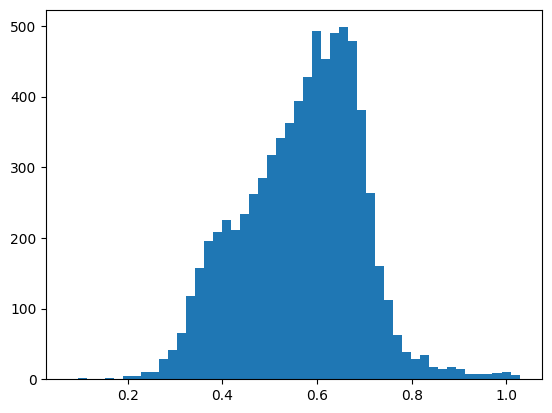

In [37]:
import numpy as np
import pandas as pd
import random
from numpy.linalg import norm


total_pairs = len(data["labels_train"])
pos = int(np.sum(data["labels_train"]))
neg = total_pairs - pos

print("Total pairs used for training:", total_pairs)
print(f"Positives: {pos:,}, Negatives: {neg:,}")

#
# Extract embeddings
#
W_target = model.get_layer('target_embedding').get_weights()[0]
W_context = model.get_layer('context_embedding').get_weights()[0]
W_final = (W_target + W_context) / 2.0

gene_embeddings = pd.DataFrame(W_final, index=genes)
print("Embedding matrix shape:", W_final.shape)

# Combine symmetrically (Word2Vec trick)
W_final = (W_target + W_context) / 2.0

print("Embedding matrix shape:", W_final.shape)

gene_embeddings = pd.DataFrame(W_final, index=genes)
print(gene_embeddings.head())

# Combine them symmetrically (Word2Vec trick)
W_final = (W_target + W_context) / 2.0

print("Embedding matrix shape:", W_final.shape)

# Put into a DataFrame
gene_embeddings = pd.DataFrame(W_final, index=genes)
print(gene_embeddings.head())

#
# Sanity checks
#
print("len(genes):", len(genes))
if 'gene_to_idx' in locals():
    print("len(gene_to_idx):", len(gene_to_idx))

idx_to_gene = {i: g for g, i in gene_to_idx.items()}
genes_full = [idx_to_gene.get(i, f"UNK_{i}") for i in range(W_final.shape[0])]
gene_embeddings = pd.DataFrame(W_final, index=genes_full)

#
# Marker genes and similarities
#
markers = {
    "T cell": ["Cd3d", "Cd3g"],
    "B cell": ["Cd19", "Cd79a", "Ms4a1"],
    "Myeloid": ["Cd68", "Lyz2", "Cd14"],
    "NK cell": ["Nkg7", "Klrb1c"],
    "Housekeeping": ["Actb", "Gapdh"]
}

# Filter to those that exist in embedding index
markers = {k: [g for g in v if g in gene_embeddings.index] for k, v in markers.items()}
print("Markers found in vocab:", markers)

# Cosine-similarity helper
def cos(g1, g2):
    v1, v2 = gene_embeddings.loc[g1].values, gene_embeddings.loc[g2].values
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

# Compute similarity of marker pairs vs random pairs
same, diff = [], []
for group, geneset in markers.items():
    for g1 in geneset:
        for g2 in geneset:
            if g1 != g2:
                same.append(cos(g1, g2))

all_genes = list(gene_embeddings.index)
for _ in range(len(same)):
    g1, g2 = random.sample(all_genes, 2)
    diff.append(cos(g1, g2))

print(f"Mean same-group similarity: {np.mean(same):.3f}")
print(f"Mean random-pair similarity: {np.mean(diff):.3f}")

#
# show top neighbors
#
def most_similar(gene, topn=8):
    if gene not in gene_embeddings.index:
        print(f"{gene} not in vocabulary")
        return None
    v = gene_embeddings.loc[gene].values
    sims = gene_embeddings.dot(v) / (norm(gene_embeddings.values, axis=1) * norm(v))
    return sims.sort_values(ascending=False).head(topn)

for g in sum(markers.values(), []):
    print(f"\nTop neighbors for {g}:")
    print(most_similar(g))
gene_embeddings_numeric = gene_embeddings.select_dtypes(include=[np.number])
print(gene_embeddings_numeric.var().describe())
from numpy.linalg import norm
norms = norm(gene_embeddings_numeric.values, axis=1)
print(f"Mean norm: {norms.mean():.4f}, std: {norms.std():.4f}")
plt.hist(norms, bins=50)


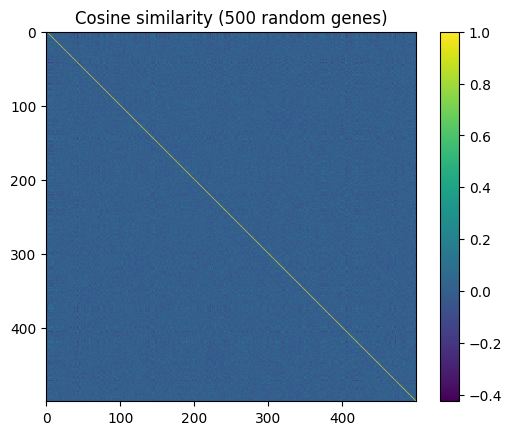

In [38]:
from sklearn.metrics.pairwise import cosine_similarity
subset = gene_embeddings_numeric.sample(500, random_state=0)
cos = cosine_similarity(subset)
plt.imshow(cos, cmap="viridis")
plt.title("Cosine similarity (500 random genes)")
plt.colorbar()


In [39]:
#
# Gene2Vec visualization with GO annotation highlighting
#

import numpy as np
import pandas as pd
import umap
import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px
import gseapy as gp
from sklearn.preprocessing import normalize
E_unit = normalize(gene_embeddings.select_dtypes(include=[np.number]))
#
# 1. Prepare embedding and compute UMAP
#
reducer = umap.UMAP(n_neighbors=55, min_dist=0.6, random_state=1234)
coords = reducer.fit_transform(gene_embeddings.select_dtypes(include=[np.number]))


df = pd.DataFrame({
    "UMAP1": coords[:, 0],
    "UMAP2": coords[:, 1],
    "gene": gene_embeddings.index
}).set_index("gene")

#
# 2. Annotate genes with GO Biological Process terms
#
import pickle
import os

if os.path.exists("gene_to_go_mouse.pkl"):
    with open("gene_to_go_mouse.pkl", "rb") as f:
        gene_to_go = pickle.load(f)
    print(f"Loaded precomputed GO mapping for {len(gene_to_go):,} genes")
else:
    raise FileNotFoundError("Run the GO fetch step first to create gene_to_go_mouse.pkl")

# Apply mapping
genes_upper = [g.upper() for g in gene_embeddings.index]
gene_embeddings["GO_term"] = [gene_to_go.get(g, ["unannotated"])[0] for g in genes_upper]

df["GO_term"] = gene_embeddings["GO_term"].values



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Loaded precomputed GO mapping for 14,697 genes


In [47]:
###############################
# Highlight top-N largest GO terms (excluding "unannotated")
# Keep "unannotated" genes as a separate gray background class
###############################

# Count how many genes per GO term
term_counts = df["GO_term"].value_counts()

# Exclude the "unannotated" category when choosing highlighted classes
N = 100
annotated_terms = term_counts.drop(labels=["unannotated"], errors="ignore")
highlight_terms = annotated_terms.head(N).index.tolist()

print(f"Top {len(highlight_terms)} annotated GO terms by size:")
print(annotated_terms.head(N))

# Assign display categories:
#   - top N annotated terms are colored
#   - "unannotated" and everything else → gray
df["GO_display"] = np.where(
    df["GO_term"].isin(highlight_terms),
    df["GO_term"],
    "unannotated"
)

#
# Build color map: bright distinct colors + gray for unannotated
#
cmap = cm.get_cmap("rainbow", N)
colors = [mcolors.to_hex(cmap(i)) for i in range(N)]
color_map = {term: color for term, color in zip(highlight_terms, colors)}
color_map["unannotated"] = "#d3d3d3"  # light gray background

#
# Interactive UMAP plot
#
fig = px.scatter(
    df,
    x="UMAP1",
    y="UMAP2",
    color="GO_display",
    color_discrete_map=color_map,
    hover_name=df.index,
    hover_data={"GO_term": True},
    title=f"Gene2Vec embedding — top {N} annotated GO terms (+ unannotated in gray)",
    width=2000,
    height=900
)
fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(legend_title_text="GO Biological Process")
fig.show()


Top 100 annotated GO terms by size:
GO_term
DNA Damage Response (GO:0006974)                                   167
Negative Regulation Of DNA-templated Transcription (GO:0045892)     96
DNA-templated Transcription (GO:0006351)                            77
Cilium Assembly (GO:0060271)                                        60
Regulation Of DNA-templated Transcription (GO:0006355)              53
                                                                  ... 
Cholesterol Biosynthetic Process (GO:0006695)                       10
RNA Phosphodiester Bond Hydrolysis (GO:0090501)                     10
NADH Dehydrogenase Complex Assembly (GO:0010257)                    10
Cellular Defense Response (GO:0006968)                              10
Fatty Acid Metabolic Process (GO:0006631)                           10
Name: count, Length: 100, dtype: int64


/tmp/ipython-input-3366412640.py:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



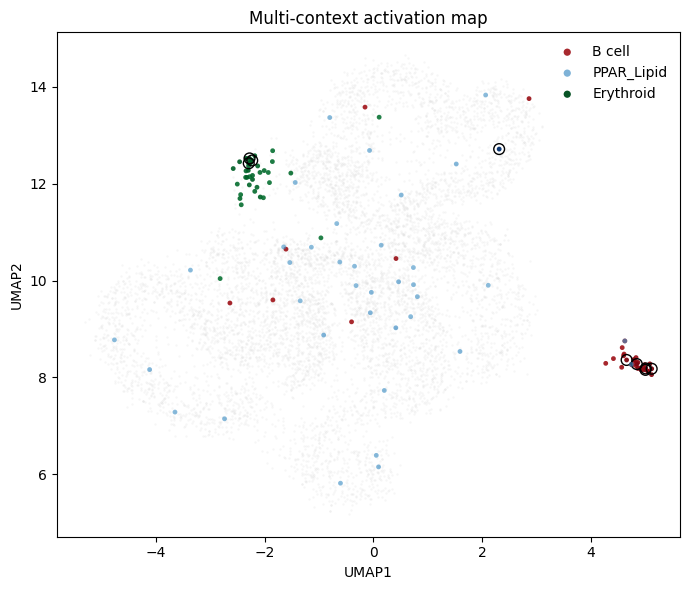

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from itertools import cycle

def plot_multi_activation(
    contexts,
    E,
    coords,
    genes,
    top_frac=0.10,
    k=8,
    cmaps=None,
    figsize=(7,6)
):
    """
    Plot several activation contexts on the same UMAP.

    contexts : dict
        { "label": [gene1, gene2, ...], ... }
    E : ndarray  (n_genes × n_dims)
        Gene embedding matrix.
    coords : ndarray (n_genes × 2)
        UMAP coordinates (same order as genes).
    genes : list-like
        Gene names (same order as rows in E, coords).
    top_frac : float
        Fraction of most-activated genes to render (e.g. 0.10 = top 10%).
    k : float
        Steepness of sigmoid.
    cmaps : list of colormap names
        If None, use default cycle.
    """

    E_unit = normalize(E)
    n = len(genes)
    gene_index = {g:i for i,g in enumerate(genes)}

    def sigmoid(x): return 1/(1+np.exp(-k*(x-0.5)))

    # pick color maps
    if cmaps is None:
        cmaps = cycle(["Reds","Blues","Greens","Purples","Oranges"])
    else:
        cmaps = cycle(cmaps)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(coords[:,0], coords[:,1],
               c="lightgray", s=3, alpha=0.2, lw=0)

    for label, gset in contexts.items():
        cmap = next(cmaps)
        present = [g for g in gset if g in gene_index]
        if not present:
            print(f"⚠️ No genes found for {label}")
            continue

        # mean direction
        v = E_unit[[gene_index[g] for g in present]].mean(0)
        v /= np.linalg.norm(v)
        sims = E_unit @ v
        sig_sims = sigmoid((sims+1)/2)

        # threshold top fraction
        thr = np.quantile(sig_sims, 1-top_frac)
        mask = sig_sims >= thr
        colors = plt.get_cmap(cmap)(sig_sims[mask])

        ax.scatter(coords[mask,0], coords[mask,1],
                   c=colors, s=12,
                   alpha=sig_sims[mask],
                   lw=0, label=label)

        # draw outline for seed genes
        sel_idx = [gene_index[g] for g in present]
        ax.scatter(coords[sel_idx,0], coords[sel_idx,1],
                   facecolors='none', edgecolors='black',
                   s=60, linewidths=1.0)

    ax.set_title("Multi-context activation map")
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.legend(frameon=False, markerscale=1.5)
    plt.tight_layout()
    plt.show()


E = gene_embeddings.select_dtypes(include=[np.number]).values
coords = df[["UMAP1","UMAP2"]].values
genes = list(df.index)

contexts = {
    # === Immune lineages ===
    "B cell"             : ["Cd19","Cd79a","Cd79b","Cd74","Ms4a1"],
    #"T cell"             : ["Cd3d","Cd3g","Lck","Zap70","Cd247","Cd28"],
    #"Myeloid"            : ["Cd68","Lyz2","Cd14","Itgam","Clec4e","Fcgr1"],
    #"NK cell"            : ["Nkg7","Gzmb","Prf1","Klrb1c","Klrk1","Ifng"],

   # # === Immune signaling / cross-talk ===
   # "Antigen_MHCII"      : ["H2-Ab1","H2-Eb1","Cd74","Ciita"],
    #"Antigen_MHCI"       : ["B2m","Tap1","Tapbp","Psmb8","Psmb9"],
   # "Costimulation"      : ["Cd28","Cd40lg","Icos","Ctla4","Pdcd1"],
   # "Cytokine_Chemokine" : ["Ccl2","Ccl3","Ccl5","Cxcl9","Cxcl10","Tnf"],
#
   # # === Interferon / inflammation ===
   # "Interferon"         : ["Stat1","Ifit1","Ifit3","Isg15","Oas1a","Irf7"],
   # "NFkB"               : ["Nfkb1","Rela","Nfkbia","Tnfaip3","Chuk"],
   # "Apoptosis_TNF"      : ["Bax","Casp3","Casp8","Fadd","Traf2"],
#
   # # === Stress & metabolic response ===
   # "Oxidative_Stress"   : ["Hmox1","Sod2","Nqo1","Hspa1a","Hsp90aa1","Dnajb1"],
   # "Hypoxia_HIF1A"      : ["Hif1a","Vegfa","Epas1","Pdk1","Aldoa","Ldha"],
    "PPAR_Lipid"         : ["Ppara","Pparg","Cpt1a","Fabp4","Lpl","Adipoq"],
#
   # # === Core metabolism & housekeeping ===
   # "Glycolysis"         : ["Gapdh","PkM","Aldoa","Eno1","Pgk1","Tpi1"],
   # "TCA_OXPHOS"         : ["Sdha","Mdh2","Ndufa9","Cox4i1","Atp5f1b","Uqcrc1"],
   # "Ribosome"           : ["Rpl3","Rpl13a","Rps6","Rps27a","Rps8","Rpl10"],
   # "Proteasome"         : ["Psma1","Psma4","Psmb8","Psmb9","Psme1"],
#
   # # === Cell cycle / proliferation ===
   # "Cell_Cycle"         : ["Mki67","Cdk1","Ccnb1","Top2a","Bub1","Aurkb"],
   # "DNA_Replication"    : ["Mcm2","Mcm5","Pcna","Rrm2","Tyms"],
#
   # # === Differentiation / lineage ===
    "Erythroid"          : ["Hba-a1","Hbb-bt","Alas2","Gypa"],
    #"Endothelial"        : ["Pecam1","Cdh5","Vwf","Kdr","Nos3"],
    #"Fibroblast_ECM"     : ["Col1a1","Fn1","Acta2","Tagln","Serpine1"],
#
   # # === Regulatory programs ===
   #"MYC_Targets"        : ["Myc","Mxd1","Eif4e","Rpl3","Cdk4","Hspd1"],
}



plot_multi_activation(contexts, E, coords, genes,
                      top_frac=0.005, k=8)


Total raw edges: 31,565
Downsampled to 8,000 strongest edges


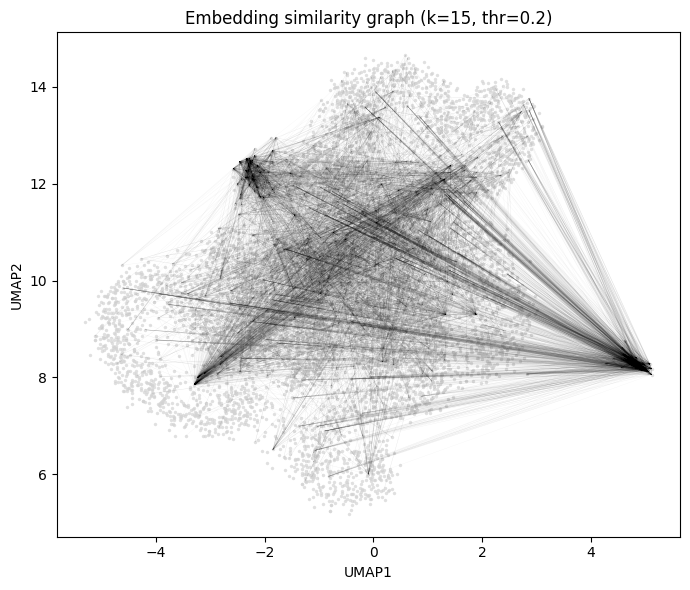

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

def plot_embedding_graph(
    E, coords, genes,
    k=10,
    sim_threshold=0.6,
    max_edges=10000,
    node_size=6,
    edge_alpha=0.3,
    figsize=(7,6),
    cmap="viridis"
):
    """
    Plot a UMAP scatter with embedding-similarity edges overlaid.

    Parameters
    ----------
    E : ndarray (n_genes × n_dims)
        Embedding matrix (raw or normalized).
    coords : ndarray (n_genes × 2)
        2D UMAP coordinates for the same genes.
    genes : list-like
        Gene names.
    k : int
        Number of top similar neighbors to connect per node.
    sim_threshold : float
        Minimum cosine similarity to draw an edge.
    max_edges : int
        Limit number of edges for clarity / speed.
    node_size : int
        Marker size for scatter points.
    edge_alpha : float
        Max transparency for strongest edges.
    figsize : tuple
        Figure size.
    cmap : str
        Colormap for nodes.
    """
    # normalize for cosine similarity
    E_unit = normalize(E)
    n = len(genes)
    sims = E_unit @ E_unit.T

    # zero out self-similarity
    np.fill_diagonal(sims, 0)

    # for each gene, take top-k neighbors
    edges = []
    for i in range(n):
        topk_idx = np.argsort(sims[i])[-k:]
        for j in topk_idx:
            if sims[i, j] >= sim_threshold:
                edges.append((i, j, sims[i, j]))
    print(f"Total raw edges: {len(edges):,}")

    # subsample if too many
    if len(edges) > max_edges:
        edges = sorted(edges, key=lambda x: x[2], reverse=True)[:max_edges]
        print(f"Downsampled to {len(edges):,} strongest edges")

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(coords[:,0], coords[:,1],
               c="lightgray", s=node_size, alpha=0.7, lw=0)

    # draw edges with transparency proportional to similarity
    for (i, j, w) in edges:
        x1, y1 = coords[i]
        x2, y2 = coords[j]
        alpha = edge_alpha * (w - sim_threshold) / (1 - sim_threshold)
        ax.plot([x1, x2], [y1, y2], color='k', alpha=alpha, lw=0.3)

    ax.set_title(f"Embedding similarity graph (k={k}, thr={sim_threshold})")
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    plt.tight_layout()
    plt.show()

    return edges
E = gene_embeddings.select_dtypes(include=[np.number]).values
coords = df[["UMAP1","UMAP2"]].values
genes = list(df.index)

edges = plot_embedding_graph(
    E, coords, genes,
    k=15,
    sim_threshold=0.2,
    max_edges=8000,
    edge_alpha=0.3
)


.